# Week 05 - (1) 탐색적 데이터 분석 (EDA) 해설 
## 🌾 농작물 추천 데이터셋 (Crop Recommendation Dataset)

---

### 📋 학습 목표
1. Google Colab 환경에서 Python 데이터 분석 라이브러리를 사용할 수 있다
2. Pandas를 활용하여 데이터의 기본 구조와 통계량을 파악할 수 있다
3. 결측치, 이상치 등 데이터 품질 문제를 확인할 수 있다
4. 농업 데이터의 맥락에서 탐색 결과를 해석할 수 있다

### 📊 데이터셋 소개
**Crop Recommendation Dataset**은 토양의 영양소 함량(N, P, K)과 기후 조건(온도, 습도, pH, 강수량)을 기반으로 적합한 작물을 추천하는 데이터셋입니다.

| 변수 | 설명 | 단위 |
|------|------|------|
| N | 토양 내 질소 함량 비율 | kg/ha |
| P | 토양 내 인 함량 비율 | kg/ha |
| K | 토양 내 칼륨 함량 비율 | kg/ha |
| temperature | 온도 | °C |
| humidity | 상대습도 | % |
| ph | 토양 pH | - |
| rainfall | 강수량 | mm |
| label | 추천 작물 | - |


---
## 1. 환경 설정 및 라이브러리 불러오기

데이터 분석에 필요한 기본 라이브러리를 불러옵니다.
- **pandas**: 데이터프레임 조작 및 분석
- **numpy**: 수치 연산
- **matplotlib / seaborn**: 시각화


In [ ]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: matplotlib.pyplot을 plt로, seaborn을 sns로 불러오세요
# 힌트: import ______ as ______

warnings.filterwarnings('ignore')


Colab 환경에서 한글 폰트 설정을 위한 라이브러리 설치
(한글이 깨져서 나타날 경우 설치)

In [ ]:
!pip install koreanize-matplotlib

import koreanize_matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 65.7 MB/s eta 0:00:00


---
## 2. 데이터 불러오기

Crop Recommendation 데이터셋을 GitHub에서 직접 다운로드하여 불러옵니다.


In [ ]:
# 데이터 다운로드 및 로딩
url = "https://raw.githubusercontent.com/agtechresearch/MLapplications-graduate/refs/heads/main/dataset/Crop_Recommendation_dataset.csv"

# TODO: pd.read_csv()를 사용하여 데이터를 불러오고 df 변수에 저장하세요
df = pd.read_csv(url)

df.shape

(2200, 8)

---
## 3. 데이터 첫인상 파악하기

데이터를 처음 받으면 가장 먼저 해야 할 일은 **"이 데이터가 어떻게 생겼는지"** 파악하는 것입니다.


### 3.1 처음 5행 확인하기
`.head()`를 사용하면 데이터의 처음 몇 행을 볼 수 있습니다. 각 열이 어떤 값을 담고 있는지 감을 잡아봅시다.


In [ ]:
# TODO: df의 처음 5행을 출력하세요

#df.head()

df.tail()


,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


### 3.2 데이터 타입 및 구조 확인
`.info()`는 각 열의 데이터 타입, 결측치 수 등을 한눈에 보여줍니다.
- `float64`: 소수점이 있는 실수형 (예: 온도, pH)
- `int64`: 정수형 (예: N, P, K)
- `object`: 문자열 (예: 작물 이름)


In [ ]:
# TODO: df.info()를 호출하여 데이터 구조를 확인하세요

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


### 3.3 열 이름 확인


In [ ]:
df.columns

#list(df.columns)

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

---
## 4. 기술통계량 (Descriptive Statistics)

`.describe()`는 수치형 변수에 대해 평균, 표준편차, 최솟값, 사분위수, 최댓값 등을 요약해줍니다.

> 🌱 **농학적 맥락**: 토양 N/P/K 값의 범위, pH의 분포 등을 통해 이 데이터가 어떤 농업 환경을 대표하는지 가늠할 수 있습니다.


In [ ]:
# TODO: describe()를 사용하여 기술통계량을 확인하세요
# 힌트: .T (전치)를 붙이면 변수가 행으로, 통계량이 열로 배치되어 보기 편합니다

df.describe()


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


#### 💡 해석 포인트

위 통계량을 보고 다음 질문에 답해보세요:

1. **질소(N)의 범위**는 어떻게 되나요? 최솟값과 최댓값의 차이가 크다면 무엇을 의미할까요?
2. **pH의 평균값**은 약 얼마인가요? 이것은 산성, 중성, 알칼리성 중 어디에 해당하나요?
3. **온도와 강수량**의 표준편차(std)가 크다면 어떤 의미일까요?


#### ✍️ 여러분의 해석을 적어보세요
*(이 셀을 더블클릭하여 답변을 작성하세요)*

1. 질소(N):
2. pH:
3. 온도/강수량:


---
## 5. 타겟 변수(label) 분석

우리가 예측하고자 하는 **타겟 변수**인 `label`(작물 종류)을 분석합니다.


### 5.1 작물 종류 확인


In [ ]:
# TODO: label 열의 고유값(unique values)을 확인하세요
# 힌트: df['label'].______()

crops = df['label'].unique()
crops

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [ ]:
print(f"총 {len(crops)}개 작물 종류")
print("작물 목록:", sorted(crops))

총 22개 작물 종류
작물 목록: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


In [ ]:
len(crops)

22

### 5.2 작물별 데이터 수 (클래스 균형 확인)

머신러닝에서 **클래스 균형(class balance)**은 중요합니다. 특정 작물의 데이터가 지나치게 많거나 적으면 모델이 편향될 수 있습니다.


In [ ]:
# TODO: 각 작물(label)별 데이터 수를 세어보세요
# 힌트: df['label'].value_counts()
crop_counts = df['label'].value_counts()

print(crop_counts)

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


### 5.3 클래스 균형 시각화


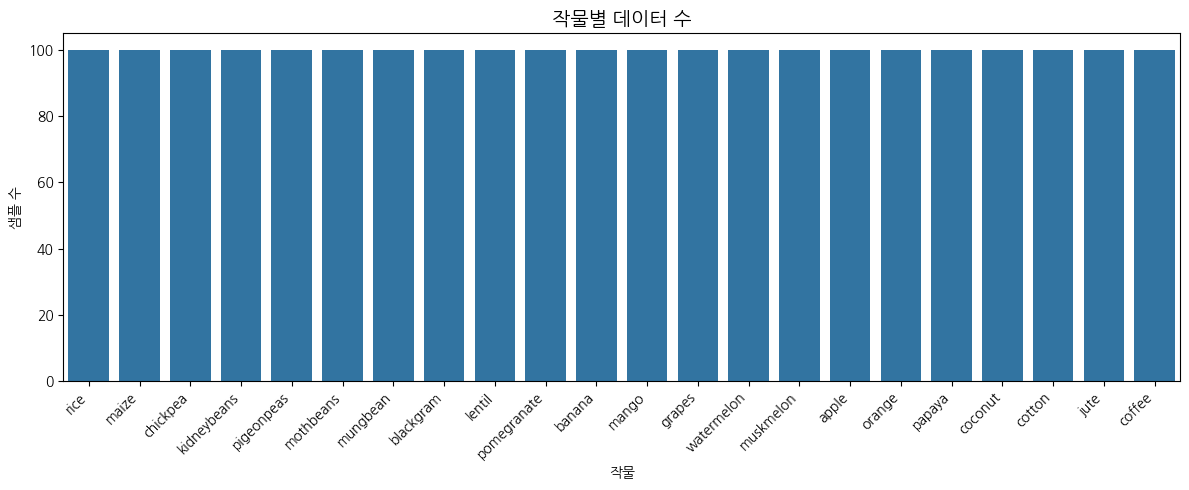

In [ ]:
# 작물별 데이터 수를 막대그래프로 시각화
plt.figure(figsize=(12, 5))

# TODO: sns.countplot을 사용하여 label별 빈도를 그리세요
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)


plt.title('작물별 데이터 수', fontsize=14)
plt.xlabel('작물')
plt.ylabel('샘플 수')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 6. 결측치 (Missing Values) 확인

실제 연구 데이터에서는 센서 오류, 기록 누락 등으로 결측치가 빈번합니다. 데이터 분석의 첫 단계에서 반드시 확인해야 합니다.


In [ ]:
# TODO: 각 열의 결측치 수를 확인하세요
# 힌트: df.isnull().sum()
missing = df.isnull().sum()

print("=== 결측치 현황 ===")
print(missing)
print(f"\n총 결측치 수: {missing.sum()}")

=== 결측치 현황 ===
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

총 결측치 수: 0


> 🎉 이 데이터셋은 결측치가 없는 깨끗한 데이터입니다. 실제 연구에서는 결측치 처리(삭제, 대체 등)가 중요한 전처리 단계가 됩니다.


---
## 7. 작물별 특성 비교 (Groupby 분석)

**groupby**는 데이터를 그룹별로 나누어 통계를 계산하는 강력한 도구입니다. 작물별로 환경 조건이 어떻게 다른지 비교해봅시다.


### 7.1 작물별 평균 환경 조건


In [ ]:
# TODO: 작물(label)별로 모든 수치 변수의 평균을 구하세요
# 힌트: df.groupby('______').mean()
crop_means = df.groupby('label').mean()

# 소수점 2자리까지 반올림하여 보기 좋게 출력
#crop_means.round(2)

crop_means

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646
coffee,101.20,28.74,29.94,25.540477,58.869846,6.790308,158.066295
cotton,117.77,46.24,19.56,23.988958,79.843474,6.912675,80.398043
grapes,23.18,132.53,200.11,23.849575,81.875228,6.025937,69.611829
jute,78.40,46.86,39.99,24.958376,79.639864,6.732778,174.792798


### 7.2 특정 작물 심층 분석

관심 있는 작물 몇 가지를 골라서 자세히 비교해봅시다. 예를 들어 **벼(rice)**, **밀(wheat)**, **옥수수(maize)**는 세계 3대 곡물입니다.


In [ ]:
# 비교할 작물 선택
selected_crops = ['rice', 'wheat', 'maize']

# TODO: 선택한 작물의 데이터만 필터링하세요
# 힌트: df[df['label'].isin(______)]
selected_df = df[df['label'].isin(selected_crops)]

# 작물별 기술통계량 비교
for crop in selected_crops:
    print(f"\n{'='*50}")
    print(f"🌾 {crop.upper()}")
    print(f"{'='*50}")
    print(selected_df[selected_df['label'] == crop].describe().round(2).T[['mean', 'std', 'min', 'max']])


🌾 RICE
               mean    std     min     max
N             79.89  11.92   60.00   99.00
P             47.58   7.90   35.00   60.00
K             39.87   2.95   35.00   45.00
temperature   23.69   2.03   20.05   26.93
humidity      82.27   1.42   80.12   84.97
ph             6.43   0.77    5.01    7.87
rainfall     236.18  34.29  182.56  298.56

🌾 WHEAT
             mean  std  min  max
N             NaN  NaN  NaN  NaN
P             NaN  NaN  NaN  NaN
K             NaN  NaN  NaN  NaN
temperature   NaN  NaN  NaN  NaN
humidity      NaN  NaN  NaN  NaN
ph            NaN  NaN  NaN  NaN
rainfall      NaN  NaN  NaN  NaN

🌾 MAIZE
              mean    std    min     max
N            77.76  11.95  60.00  100.00
P            48.44   8.01  35.00   60.00
K            19.79   2.94  15.00   25.00
temperature  22.39   2.68  18.04   26.55
humidity     65.09   5.45  55.28   74.83
ph            6.25   0.41   5.51    7.00
rainfall     84.77  15.55  60.65  109.75


### 7.3 어떤 작물이 가장 많은 질소(N)를 필요로 할까?


In [ ]:
# TODO: 작물별 평균 질소(N) 함량을 기준으로 내림차순 정렬하세요
# 힌트: crop_means['N'].sort_values(ascending=______)
top_n_crops = crop_means['N'].sort_values(ascending=False)

print("=== 질소 요구량 상위 5개 작물 ===")
print(top_n_crops.head())
print("\n=== 질소 요구량 하위 5개 작물 ===")
print(top_n_crops.tail())

=== 질소 요구량 상위 5개 작물 ===
label
cotton        117.77
coffee        101.20
muskmelon     100.32
banana        100.23
watermelon     99.42
Name: N, dtype: float64

=== 질소 요구량 하위 5개 작물 ===
label
pigeonpeas     20.73
mango          20.07
orange         19.58
pomegranate    18.87
lentil         18.77
Name: N, dtype: float64


---
## 8. 변수 간 상관관계 확인

변수들 간의 **상관관계(correlation)**를 확인하면, 어떤 변수들이 서로 관련이 있는지 파악할 수 있습니다.
- **+1에 가까움**: 강한 양의 상관 (하나가 증가하면 다른 것도 증가)
- **-1에 가까움**: 강한 음의 상관 (하나가 증가하면 다른 것은 감소)
- **0에 가까움**: 거의 상관이 없음


In [ ]:
# TODO: 수치형 변수들의 상관계수 행렬을 계산하세요
# 힌트: df.select_dtypes(include=[np.number]).corr()
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

corr_matrix.round(3)

,N,P,K,temperature,humidity,ph,rainfall
N,1.000,-0.231,-0.141,0.027,0.191,0.097,0.059
P,-0.231,1.000,0.736,-0.128,-0.119,-0.138,-0.064
K,-0.141,0.736,1.000,-0.160,0.191,-0.170,-0.053
temperature,0.027,-0.128,-0.160,1.000,0.205,-0.018,-0.030
humidity,0.191,-0.119,0.191,0.205,1.000,-0.008,0.094
ph,0.097,-0.138,-0.170,-0.018,-0.008,1.000,-0.109
rainfall,0.059,-0.064,-0.053,-0.030,0.094,-0.109,1.000


상관계수를 히트맵으로 시각화하면 패턴을 더 쉽게 파악할 수 있습니다.


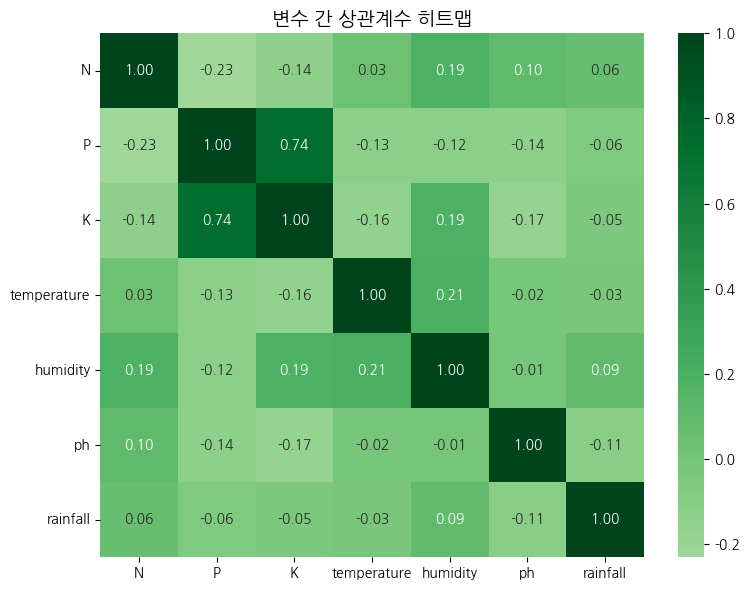

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(corr_matrix, annot=True, cmap='Greens', center=0, fmt='.2f')

plt.title('변수 간 상관계수 히트맵', fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. 정리 및 과제

### 📝 오늘 배운 것
1. **데이터 로딩**: `pd.read_csv()`로 CSV 파일 불러오기
2. **기본 탐색**: `.head()`, `.shape`, `.info()`, `.describe()`
3. **결측치 확인**: `.isnull().sum()`
4. **그룹별 분석**: `.groupby().mean()`, `.value_counts()`
5. **상관관계**: `.corr()` 및 히트맵 시각화

### 🏠 과제
다음 질문에 대해 코드를 작성하고 결과를 해석하세요:


In [ ]:
# 과제 1: 가장 높은 강수량(rainfall)을 필요로 하는 상위 3개 작물은?
# 아래에 코드를 작성하세요




In [ ]:
# 과제 2: pH가 7 이상인 (알칼리성) 토양에서 주로 재배되는 작물은?
# 힌트: df[df['ph'] >= 7]['label'].value_counts()




In [ ]:
# 과제 3: 온도(temperature)와 습도(humidity)의 상관계수는 얼마인가요?
# 이 값이 농업적으로 어떤 의미가 있을지 해석해보세요.




---
### 🔜 다음 Exercise 예고: 데이터 시각화
Matplotlib과 Seaborn을 본격적으로 활용하여 작물별 환경 조건의 분포, 관계, 패턴을 시각적으로 탐색합니다.
